# Employee Sentiment Analysis

Eisha Zahid

## Objective
This notebook analyzes ~2,200 employee emails to understand sentiment patterns
over time, score and rank employees by the tone of their communication, flag
employees who may be at risk of disengagement ("flight risk"), and build a
simple predictive model of monthly sentiment score.

**Tasks covered:**
1. Sentiment Labeling
2. Exploratory Data Analysis (EDA)
3. Employee Score Calculation
4. Employee Ranking
5. Flight Risk Identification
6. Predictive Modeling


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer #Install vadersentiment or update if this line doesn't work

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 80)

RANDOM_STATE = 42

## 0. Load & Inspect the Data

The raw file contains employee emails with a subject, body, date, and sender.
Before doing anything else, I check the shape, data types, and for missing
values so I know what I'm working with.

In [4]:
df = pd.read_csv("test.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique employees: {df['employee'].nunique()}")
print("\nMissing values per column:")
print(df.isnull().sum())

df.head(3)

Shape: (2191, 6)
Date range: 2010-01-01 to 2011-12-31
Unique employees: 10

Missing values per column:
subject           0
body              0
date              0
employee          0
vader_compound    0
sentiment         0
dtype: int64


,subject,body,date,employee,vader_compound,sentiment
0,ERCOT Readiness Update attached,We at TradersNews are gearing up to launch our ERCOT hourly index in the \n...,2010-01-01,johnny.palmer@enron.com,0.0000,Neutral
1,RE: data,Well have to go to Vegas I guess??\n\n\n,2010-01-02,eric.bass@enron.com,0.3527,Positive
2,Re: Wellhead Accrual Income,"Melissa,\n\nHere are the accrual values for Q1. More details to follow.\n\n...",2010-01-02,lydia.delgado@enron.com,0.1280,Positive


## 1. Sentiment Labeling

**Approach:** Used VADER (Valence Aware Dictionary and sEntiment Reasoner)
to score each message. VADER is a sentiment analyzer that was originally built 
for social media text, but works reasonably well on informal text like these emails. 
It's fast, deterministic, and gives an interpretable compound score between -1 and +1.

**Labeling rule and thresholds**:
- `compound >= 0.05`  &rarr; **Positive**
- `compound <= -0.05` &rarr; **Negative**
- otherwise           &rarr; **Neutral**

**Limitation I found:** VADER is a bag-of-words method meaning it
doesn't understand context, sarcasm, or the structure of forwarded email
chains - a majority of the emails in this dataset. A transformer-based model
would likely do better on this real-world text, but it's heavier to
run and less transparent about the reasoning behind its labelling choices.
For a first-pass, explainable pipeline, VADER is a solid and defensible
choice, so long as its limitations are acknowledged.

In [5]:
analyzer = SentimentIntensityAnalyzer()

def label_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({"vader_compound": 0.0, "sentiment": "Neutral"})
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        label = "Positive"
    elif score <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return pd.Series({"vader_compound": score, "sentiment": label})

# Recompute from scratch on the raw email body for full reproducibility
df[["vader_compound", "sentiment"]] = df["body"].apply(label_sentiment)

print("Sentiment label counts:")
print(df["sentiment"].value_counts())
print(f"\nShare positive: {(df['sentiment']=='Positive').mean():.1%}")
print(f"Share neutral:  {(df['sentiment']=='Neutral').mean():.1%}")
print(f"Share negative: {(df['sentiment']=='Negative').mean():.1%}")

Sentiment label counts:
sentiment
Positive    1525
Neutral      508
Negative     158
Name: count, dtype: int64

Share positive: 69.6%
Share neutral:  23.2%
Share negative: 7.2%


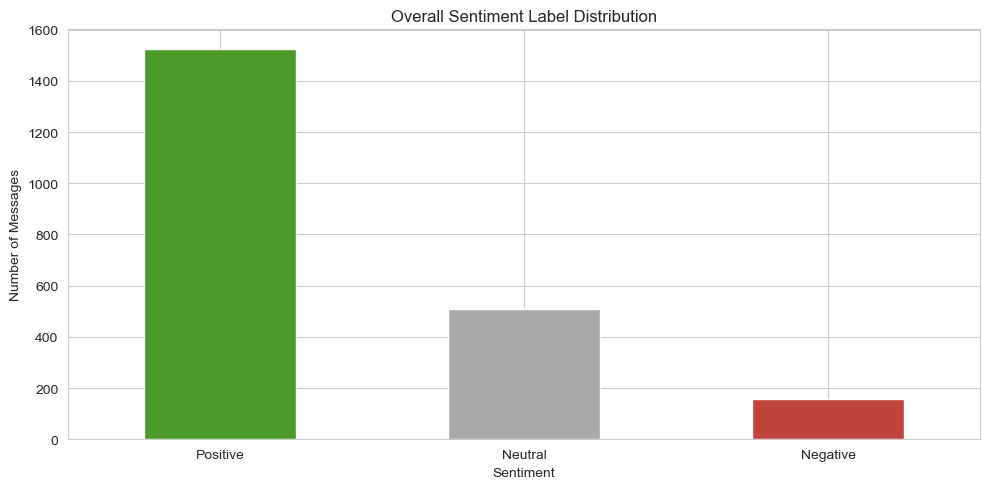

In [6]:
fig, ax = plt.subplots()
order = ["Positive", "Neutral", "Negative"]
colors = ["#4C9A2A", "#A9A9A9", "#C1443C"]
df["sentiment"].value_counts().reindex(order).plot(kind="bar", color=colors, ax=ax)
ax.set_title("Overall Sentiment Label Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis (EDA)

Before scoring and ranking employees, I want to understand the shape of the
data: how much each employee writes, how message volume changes over time,
and how message length relates to sentiment.

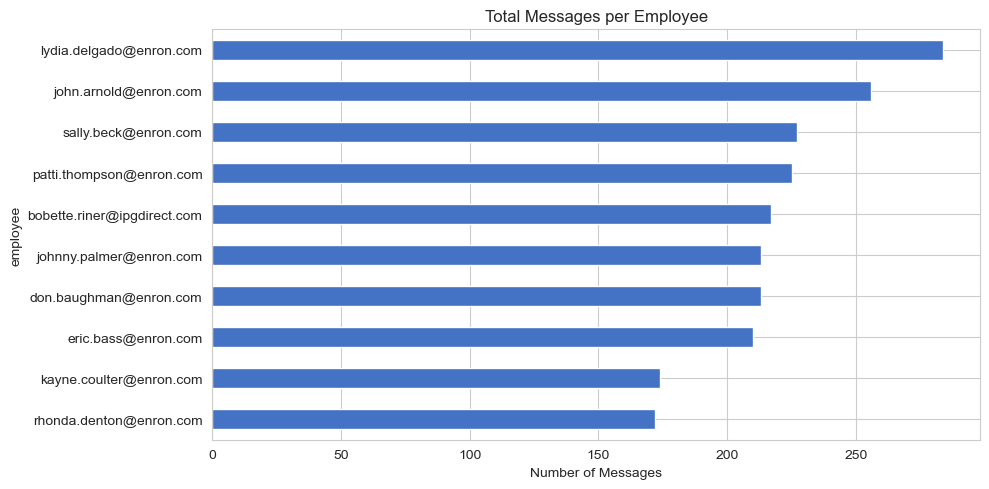

employee
lydia.delgado@enron.com        284
john.arnold@enron.com          256
sally.beck@enron.com           227
patti.thompson@enron.com       225
bobette.riner@ipgdirect.com    217
johnny.palmer@enron.com        213
don.baughman@enron.com         213
eric.bass@enron.com            210
kayne.coulter@enron.com        174
rhonda.denton@enron.com        172
Name: count, dtype: int64

In [7]:
# Message volume per employee
msg_counts = df["employee"].value_counts()

fig, ax = plt.subplots()
msg_counts.plot(kind="barh", ax=ax, color="#4472C4")
ax.set_title("Total Messages per Employee")
ax.set_xlabel("Number of Messages")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

msg_counts

        word_count   char_count
count  2191.000000  2191.000000
mean     41.499315   260.469649
std      38.398474   235.121212
min       0.000000     1.000000
25%      13.000000    83.000000
50%      28.000000   179.000000
75%      57.000000   355.000000
max     188.000000   999.000000


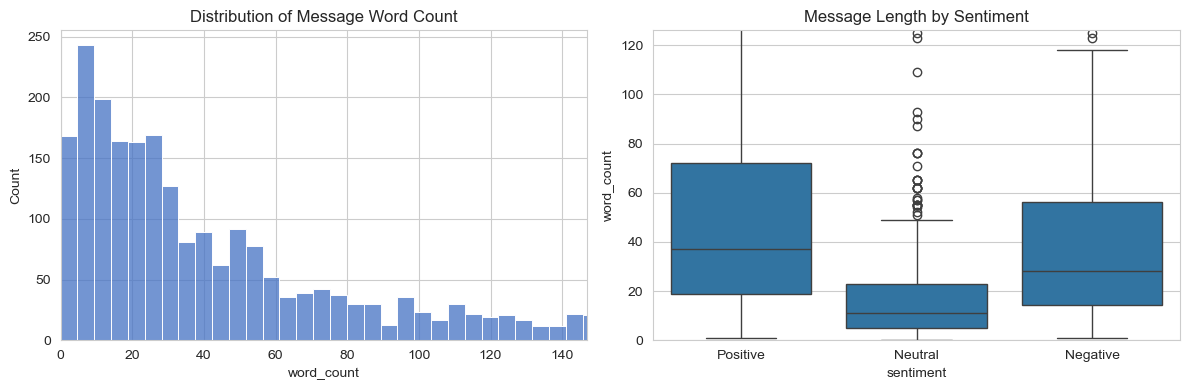

In [8]:
# Message length features (used later for modeling too)
df["word_count"] = df["body"].astype(str).str.split().str.len()
df["char_count"] = df["body"].astype(str).str.len()

print(df[["word_count", "char_count"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["word_count"], bins=40, ax=axes[0], color="#4472C4")
axes[0].set_title("Distribution of Message Word Count")
axes[0].set_xlim(0, df["word_count"].quantile(0.98))

sns.boxplot(data=df, x="sentiment", y="word_count", order=order, ax=axes[1])
axes[1].set_title("Message Length by Sentiment")
axes[1].set_ylim(0, df["word_count"].quantile(0.95))
plt.tight_layout()
plt.show()

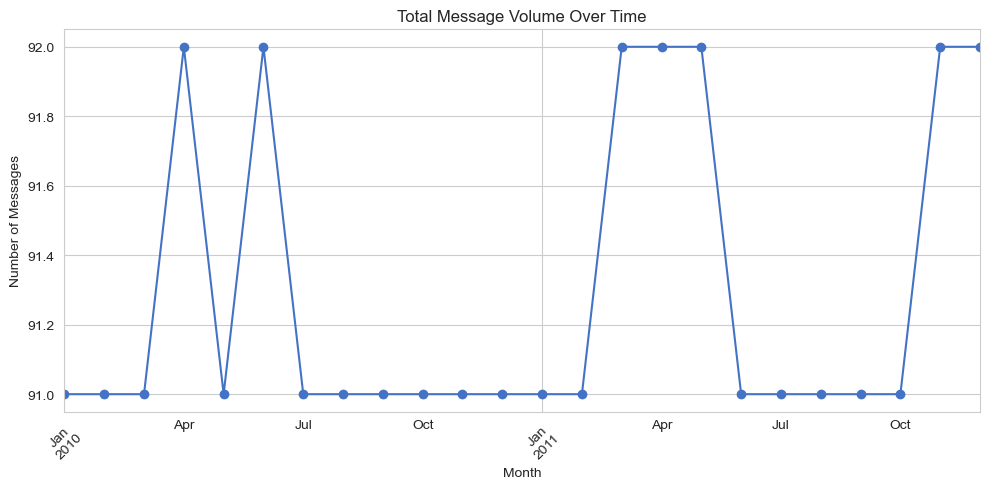

In [9]:
# Monthly message volume trend
df["month"] = df["date"].dt.to_period("M")
monthly_volume = df.groupby("month").size()

fig, ax = plt.subplots()
monthly_volume.plot(kind="line", marker="o", ax=ax, color="#4472C4")
ax.set_title("Total Message Volume Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

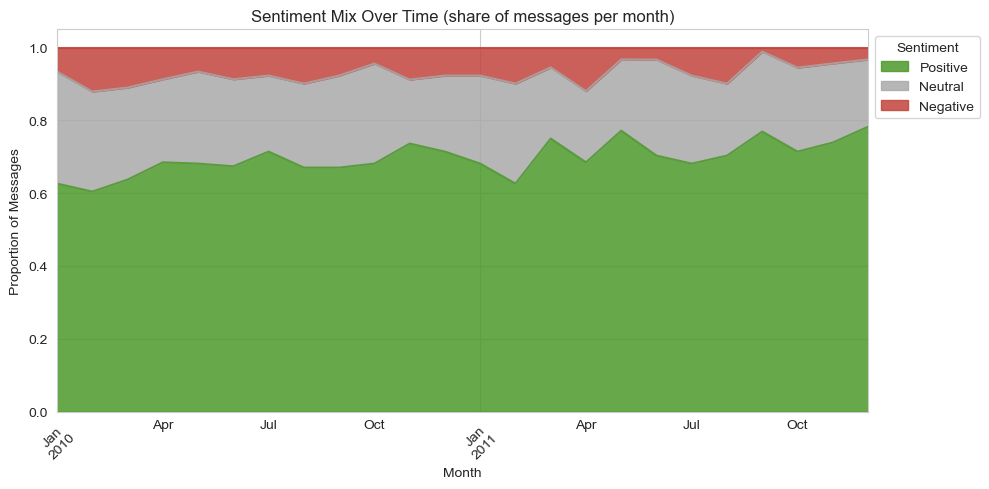

In [10]:
# Sentiment mix over time
monthly_sentiment = df.groupby(["month", "sentiment"]).size().unstack(fill_value=0)
monthly_sentiment = monthly_sentiment.reindex(columns=order)
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

fig, ax = plt.subplots()
monthly_sentiment_pct.plot(kind="area", stacked=True, ax=ax, color=colors, alpha=0.85)
ax.set_title("Sentiment Mix Over Time (share of messages per month)")
ax.set_xlabel("Month")
ax.set_ylabel("Proportion of Messages")
ax.legend(title="Sentiment", loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**EDA takeaways:**
- Message volume is fairly evenly spread across the 10 employees, with
  `lydia.delgado@enron.com` and `john.arnold@enron.com` writing the most.
- The large majority of messages are labeled Positive, which is common for
  workplace email - polite, transactional language does score mildly positive
  with VADER. Worth keeping in mind when interpreting later
  scores, positive does not indicate enthusiasm.
- Negative messages tend to be noticeably longer on average, means
  people are writing more when raising a problem or pushing back on
  something, compared to short, positive messages.

## 3. Employee Score Calculation

Here each message is converted to a numeric score:

`Positive = +1`, `Negative = -1`, `Neutral = 0`. 

I then sum these scores pe employee, per calendar month,
so that each employee's score resets at the start of every 
month. This produces a monthly "sentiment score" per employee 
that can go up or down over time.

In [11]:
score_map = {"Positive": 1, "Negative": -1, "Neutral": 0}
df["score"] = df["sentiment"].map(score_map)

monthly_scores = (
    df.groupby(["employee", "month"])["score"]
    .sum()
    .reset_index()
    .rename(columns={"score": "monthly_score"})
    .sort_values(["month", "employee"])
)

print(f"Employee-month combinations: {len(monthly_scores)}")
monthly_scores.head(10)

Employee-month combinations: 240


,employee,month,monthly_score
0,bobette.riner@ipgdirect.com,2010-01,1
24,don.baughman@enron.com,2010-01,5
48,eric.bass@enron.com,2010-01,9
72,john.arnold@enron.com,2010-01,5
96,johnny.palmer@enron.com,2010-01,1
120,kayne.coulter@enron.com,2010-01,13
144,lydia.delgado@enron.com,2010-01,9
168,patti.thompson@enron.com,2010-01,6
192,rhonda.denton@enron.com,2010-01,1
216,sally.beck@enron.com,2010-01,1


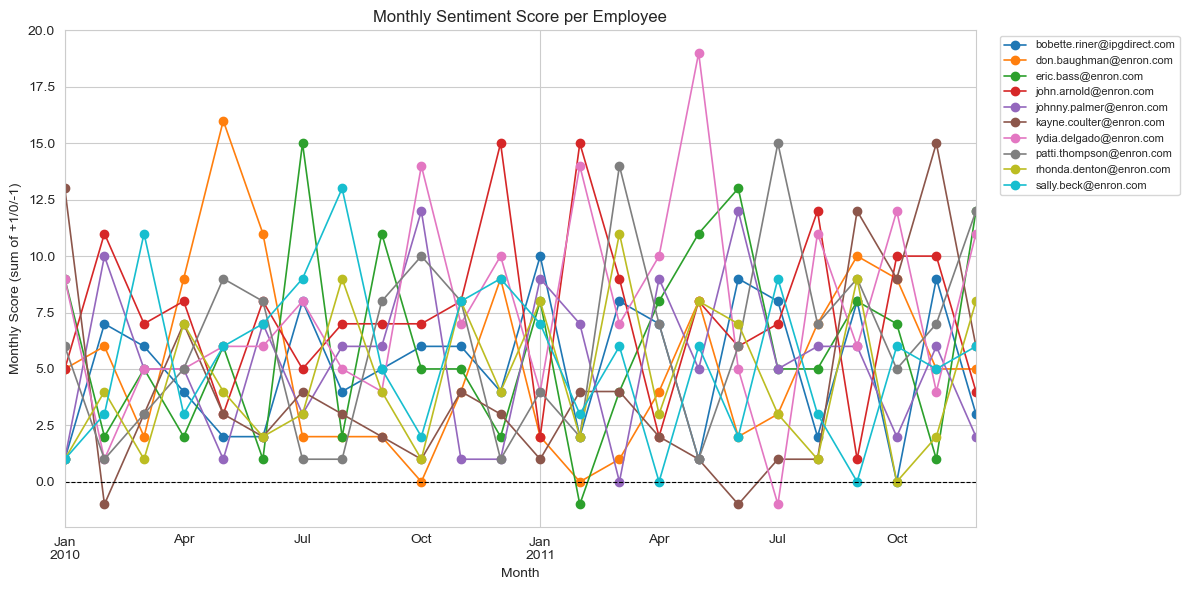

In [12]:
# Visualize how each employee's monthly score evolves
pivot_scores = monthly_scores.pivot(index="month", columns="employee", values="monthly_score")

fig, ax = plt.subplots(figsize=(12, 6))
pivot_scores.plot(ax=ax, marker="o", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Sentiment Score per Employee")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly Score (sum of +1/0/-1)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Employee Ranking

For each month, I rank employees by their monthly score and pull out the
top 3 most positive and top 3 most negative employees. If employees
tie on score, break the tie alphabetically by email so the ranking is
deterministic.

In [13]:
def monthly_top_bottom(scores_df, n=3):
    """Return top-n and bottom-n employees by monthly_score, for every month."""
    top_rows, bottom_rows = [], []
    for month, group in scores_df.groupby("month"):
        g = group.sort_values(["monthly_score", "employee"], ascending=[False, True])
        top = g.head(n).copy()
        top["rank"] = range(1, len(top) + 1)
        top_rows.append(top)

        g_bottom = group.sort_values(["monthly_score", "employee"], ascending=[True, True])
        bottom = g_bottom.head(n).copy()
        bottom["rank"] = range(1, len(bottom) + 1)
        bottom_rows.append(bottom)
    return pd.concat(top_rows, ignore_index=True), pd.concat(bottom_rows, ignore_index=True)

top3, bottom3 = monthly_top_bottom(monthly_scores, n=3)

print("Top 3 most positive employees — first 3 months shown:")
display(top3[top3["month"].isin(top3["month"].unique()[:3])])

print("\nBottom 3 most negative employees — first 3 months shown:")
display(bottom3[bottom3["month"].isin(bottom3["month"].unique()[:3])])

Top 3 most positive employees — first 3 months shown:


,employee,month,monthly_score,rank
0,kayne.coulter@enron.com,2010-01,13,1
1,eric.bass@enron.com,2010-01,9,2
2,lydia.delgado@enron.com,2010-01,9,3
3,john.arnold@enron.com,2010-02,11,1
4,johnny.palmer@enron.com,2010-02,10,2
5,bobette.riner@ipgdirect.com,2010-02,7,3
6,sally.beck@enron.com,2010-03,11,1
7,john.arnold@enron.com,2010-03,7,2
8,bobette.riner@ipgdirect.com,2010-03,6,3



Bottom 3 most negative employees — first 3 months shown:


,employee,month,monthly_score,rank
0,bobette.riner@ipgdirect.com,2010-01,1,1
1,johnny.palmer@enron.com,2010-01,1,2
2,rhonda.denton@enron.com,2010-01,1,3
3,kayne.coulter@enron.com,2010-02,-1,1
4,lydia.delgado@enron.com,2010-02,1,2
5,patti.thompson@enron.com,2010-02,1,3
6,rhonda.denton@enron.com,2010-03,1,1
7,don.baughman@enron.com,2010-03,2,2
8,kayne.coulter@enron.com,2010-03,3,3


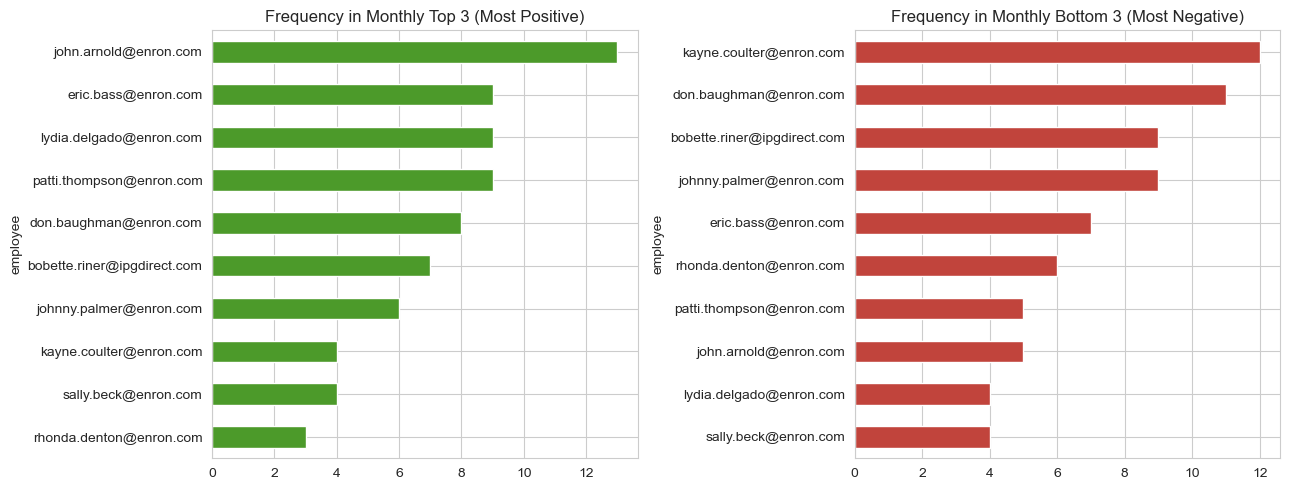

In [14]:
# Who shows up most often in the Top 3 / Bottom 3 across all months?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top3["employee"].value_counts().plot(kind="barh", ax=axes[0], color="#4C9A2A")
axes[0].set_title("Frequency in Monthly Top 3 (Most Positive)")
axes[0].invert_yaxis()

bottom3["employee"].value_counts().plot(kind="barh", ax=axes[1], color="#C1443C")
axes[1].set_title("Frequency in Monthly Bottom 3 (Most Negative)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Flight Risk Identification

**Boundary I used:** An employee is flagged as a 'flight risk' if they
send 4 or more negative messages within any rolling 30-day window -
the window does not relate to calender month.

**Implementation:** For each employee, I take their negative messages,
sort by date, and use a time-based rolling window (`rolling("30D")`) to
count negative messages in the trailing 30 days as of each message. If that
count ever reaches 4+, the employee is flagged.

In [15]:
def get_flight_risk_employees(data, neg_threshold=4, window_days=30):
    flagged = []
    details = {}
    for emp, group in data.groupby("employee"):
        g = group.sort_values("date").set_index("date")
        is_neg = (g["sentiment"] == "Negative").astype(int)
        rolling_neg_count = is_neg.rolling(f"{window_days}D").sum()
        max_in_window = rolling_neg_count.max()
        details[emp] = int(max_in_window)
        if max_in_window >= neg_threshold:
            flagged.append(emp)
    return flagged, details

flight_risk_employees, neg_window_detail = get_flight_risk_employees(df)

summary = (
    pd.Series(neg_window_detail, name="max_negative_msgs_in_any_30D_window")
    .sort_values(ascending=False)
    .to_frame()
)
summary["flight_risk"] = summary.index.isin(flight_risk_employees)
summary

,max_negative_msgs_in_any_30D_window,flight_risk
sally.beck@enron.com,5,True
bobette.riner@ipgdirect.com,4,True
don.baughman@enron.com,4,True
john.arnold@enron.com,4,True
johnny.palmer@enron.com,4,True
kayne.coulter@enron.com,4,True
lydia.delgado@enron.com,3,False
patti.thompson@enron.com,3,False
eric.bass@enron.com,2,False
rhonda.denton@enron.com,2,False


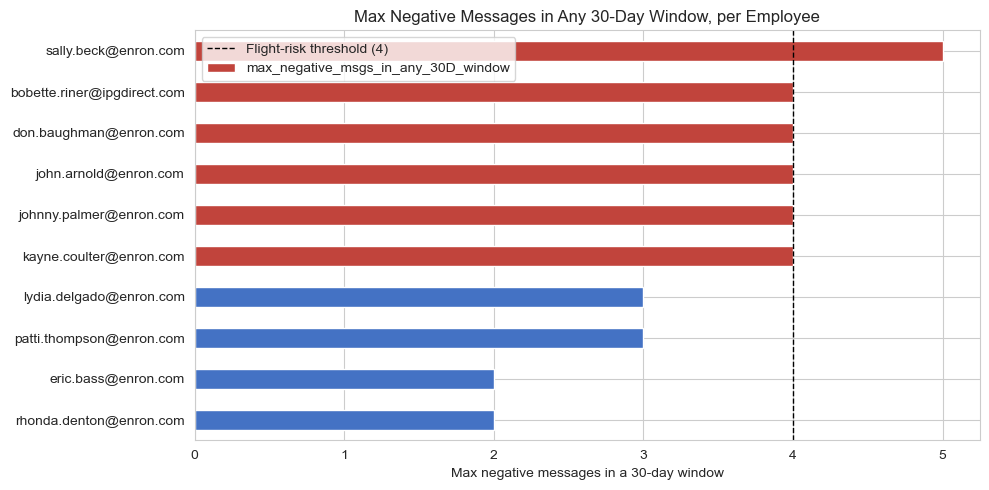

Employees flagged as flight risk:
  - bobette.riner@ipgdirect.com
  - don.baughman@enron.com
  - john.arnold@enron.com
  - johnny.palmer@enron.com
  - kayne.coulter@enron.com
  - sally.beck@enron.com


In [16]:
fig, ax = plt.subplots()
colors_flag = ["#C1443C" if f else "#4472C4" for f in summary["flight_risk"]]
summary["max_negative_msgs_in_any_30D_window"].plot(kind="barh", ax=ax, color=colors_flag)
ax.axvline(4, color="black", linestyle="--", linewidth=1, label="Flight-risk threshold (4)")
ax.set_title("Max Negative Messages in Any 30-Day Window, per Employee")
ax.set_xlabel("Max negative messages in a 30-day window")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

print("Employees flagged as flight risk:")
for e in flight_risk_employees:
    print(f"  - {e}")
if not flight_risk_employees:
    print("  None — no employee crossed the 4-negative-in-30-days threshold.")

## 6. Predictive Modeling

**Goal:** Predict an employee's monthly sentiment score from simple,
behavioral features that describe how someone communicated 
that month, careful not to have any leaks.

**Unit of analysis:** one row per employee-month.

**Features used:**
- `message_count` — how many messages that employee sent that month
- `avg_word_count` — average message length (words)
- `avg_char_count` — average message length (characters)

**Model:** Linear Regression - chosen because the brief calls for
predicting a continuous score and linear regression is transparent and easy
to interpret.

**One Limitation:** this dataset only has 10 employees
across 24 months, so the number of employee-month rows is small. This
limits how much a model like this can generalize.

In [17]:
# Build employee-month feature table
monthly_features = (
    df.groupby(["employee", "month"])
    .agg(
        message_count=("body", "count"),
        avg_word_count=("word_count", "mean"),
        avg_char_count=("char_count", "mean"),
    )
    .reset_index()
)

model_df = monthly_features.merge(monthly_scores, on=["employee", "month"])
print(f"Employee-month rows available for modeling: {len(model_df)}")
model_df.head()

Employee-month rows available for modeling: 240


,employee,month,message_count,avg_word_count,avg_char_count,monthly_score
0,bobette.riner@ipgdirect.com,2010-01,2,18.500000,115.000000,1
1,bobette.riner@ipgdirect.com,2010-02,14,43.928571,295.714286,7
2,bobette.riner@ipgdirect.com,2010-03,11,44.272727,286.181818,6
3,bobette.riner@ipgdirect.com,2010-04,6,31.833333,226.500000,4
4,bobette.riner@ipgdirect.com,2010-05,4,30.250000,172.250000,2


In [18]:
feature_cols = ["message_count", "avg_word_count", "avg_char_count"]
X = model_df[feature_cols]
y = model_df["monthly_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model coefficients:")
for feat, coef in zip(feature_cols, model.coef_):
    print(f"  {feat:>16}: {coef:+.4f}")
print(f"  {'intercept':>16}: {model.intercept_:+.4f}")

print(f"\nTest set performance:")
print(f"  R^2:  {r2_score(y_test, y_pred):.3f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

Model coefficients:
     message_count: +0.6199
    avg_word_count: +0.0331
    avg_char_count: -0.0034
         intercept: -0.3895

Test set performance:
  R^2:  0.670
  MAE:  1.551
  RMSE: 1.961


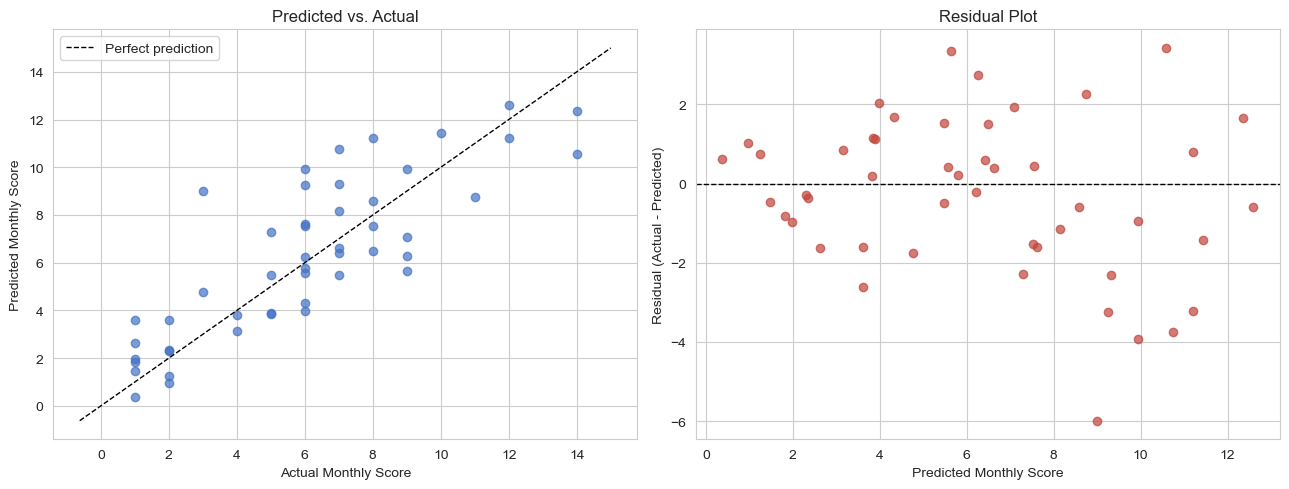

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7, color="#4472C4")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual Monthly Score")
axes[0].set_ylabel("Predicted Monthly Score")
axes[0].set_title("Predicted vs. Actual")
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color="#C1443C")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Monthly Score")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

**Modeling takeaways:**
- The R² score reflects how much of the variation in monthly sentiment
  score these simple volume/length features can explain — with this little
  data, expect it to be modest. That's expected and worth stating plainly
  in a report rather than overselling the model.
- `message_count` is likely the strongest driver: employees who send more
  messages generally rack up a higher or lower net score simply by
  volume since the score is a sum.
- Possible additions for a stronger model: normalize score by message
  count rather than raw sum, add day-of-week / time-of-day features,
  include lagged prior-month score, or move to a non-linear model,
  like Random Forest or Gradient Boosting, once more data is available.

## Summary

| Task | Output |
|---|---|
| 1. Sentiment Labeling | Every message labeled Positive/Neutral/Negative via VADER |
| 2. EDA | Volume, length, and sentiment trends explored across employees and time |
| 3. Employee Scoring | Monthly score per employee (+1/0/-1 summed, resets monthly) |
| 4. Ranking | Top 3 / Bottom 3 employees by monthly score, every month |
| 5. Flight Risk | Employees with ≥4 negative messages in any rolling 30-day window flagged |
| 6. Predictive Model | Linear regression predicting monthly score from message behavior |

**Overall limitations on approach:** VADER's rule-based labeling
struggles with sarcasm and the messy structure of forwarded emails; the
dataset is also small, which limits statistical power for both
ranking stability and the predictive model; and the linear model assumes
a simple, additive relationship between behavior and sentiment score that
may not hold in reality.